In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [28]:
# Define Data
raw_data = {
    "User ID": [f"{101+i}" for i in range(15)],
    "Region": [
        "North",
        "South",
        "East",
        "West",
        "North",
        "South",
        "East",
        "West",
        "North",
        "South",
        "East",
        "West",
        "North",
        "South",
        "East",
    ],
    "Category": [
        "Electronics",
        "Furniture",
        "Electronics",
        "Office Supplies",
        "Furniture",
        "Electronics",
        "Office Supplies",
        "Furniture",
        "Electronics",
        "Furniture",
        "Office Supplies",
        "Electronics",
        "Furniture",
        "Office Supplies",
        "Electronics",
    ],
    "Join Date": [
        "2024-01-15",
        "2024-02-12",
        "2024-03-15",
        "2024-04-20",
        "2024-05-05",
        "2024-06-10",
        "2024-07-18",
        "2024-08-25",
        "2024-09-02",
        "2024-10-14",
        "2024-11-09",
        "2024-12-30",
        "2024-01-11",
        "2024-02-01",
        "2024-03-15",
    ],
    "Sales Amount": [
        "$6,500.00",
        "$3,200.50",
        "$8,900.00",
        "$1,400.00",
        "$5,200.75",
        "$7,100.00",
        "$4,800.00",
        "$9,500.25",
        "$2,100.00",
        "$6,200.00",
        "$3,900.50",
        "$11,000.00",
        "$5,800.00",
        "$8,300.00",
        "$4,200.00",
    ],
}

df = pd.DataFrame(raw_data)

# Clean and convert columns
df["sales"] = (
    df["Sales Amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "")
    .astype(float)
)
df["date"] = pd.to_datetime(df["Join Date"])
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

# Generate estimated profit (e.g., ~20-40% of sales with slight variation)
np.random.seed(42)
df["profit"] = df["sales"] * np.random.uniform(0.15, 0.40, len(df))

In [29]:
df

,User ID,Region,Category,Join Date,Sales Amount,sales,date,month,profit
0,101,North,Electronics,2024-01-15,"$6,500.00",6500.00,2024-01-15,2024-01-01,1583.627693
1,102,South,Furniture,2024-02-12,"$3,200.50",3200.50,2024-02-12,2024-02-01,1240.765284
2,103,East,Electronics,2024-03-15,"$8,900.00",8900.00,2024-03-15,2024-03-01,2963.686521
3,104,West,Office Supplies,2024-04-20,"$1,400.00",1400.00,2024-04-20,2024-04-01,419.530469
4,105,North,Furniture,2024-05-05,"$5,200.75",5200.75,2024-05-05,2024-05-01,982.965986
5,106,South,Electronics,2024-06-10,"$7,100.00",7100.00,2024-06-10,2024-06-01,1341.890274
6,107,East,Office Supplies,2024-07-18,"$4,800.00",4800.00,2024-07-18,2024-07-01,789.700335
7,108,West,Furniture,2024-08-25,"$9,500.25",9500.25,2024-08-25,2024-08-01,3482.259982
8,109,North,Electronics,2024-09-02,"$2,100.00",2100.00,2024-09-02,2024-09-01,630.585381
9,110,South,Furniture,2024-10-14,"$6,200.00",6200.00,2024-10-14,2024-10-01,2027.512496


In [30]:
monthly_sales = df.groupby("month")["sales"].sum().reset_index()

monthly_sales

,month,sales
0,2024-01-01,12300.00
1,2024-02-01,11500.50
2,2024-03-01,13100.00
3,2024-04-01,1400.00
4,2024-05-01,5200.75
5,2024-06-01,7100.00
6,2024-07-01,4800.00
7,2024-08-01,9500.25
8,2024-09-01,2100.00
9,2024-10-01,6200.00


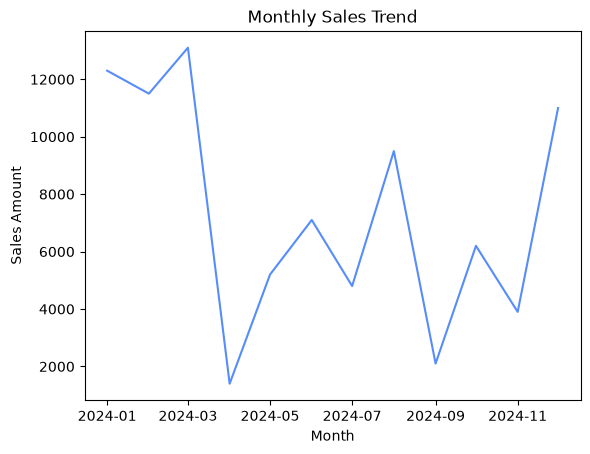

In [31]:
# Use line chart to display Monthly sales trend
plt.plot(monthly_sales["month"], monthly_sales["sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.show()

In [32]:
cat_sales = df.groupby("Category")["sales"].sum().reset_index()

cat_sales

,Category,sales
0,Electronics,39800.0
1,Furniture,29901.5
2,Office Supplies,18400.5


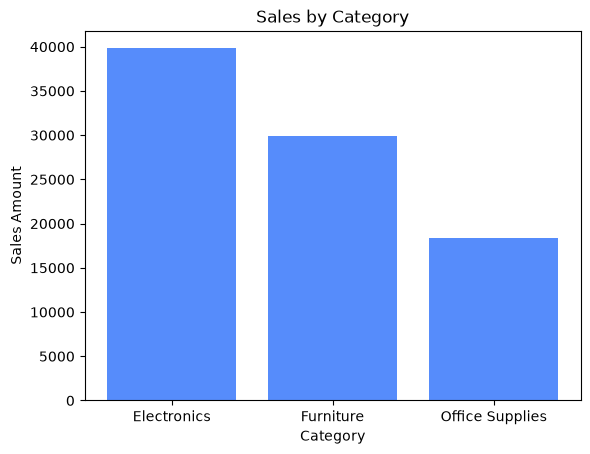

In [33]:
# Use bar chart to display sales by category
plt.bar(cat_sales["Category"], cat_sales["sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.show()

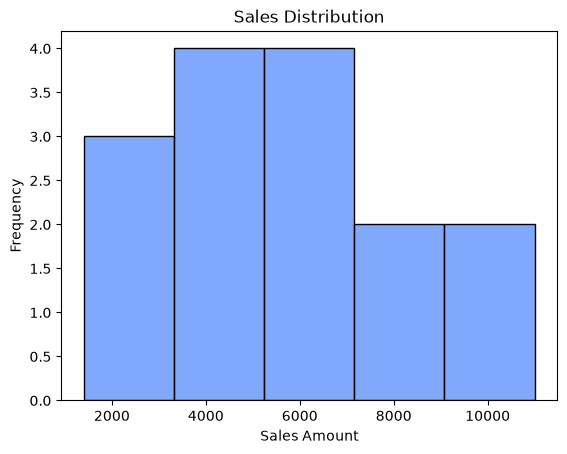

In [34]:
# Use histogram to display sales distribution
sns.histplot(df["sales"]).set_title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

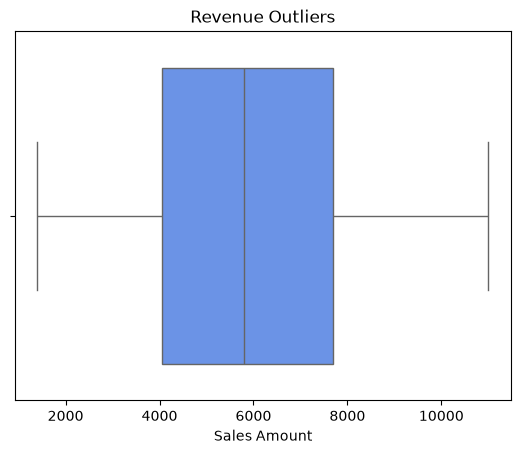

In [35]:
sns.boxplot(x=df["sales"]).set_title("Revenue Outliers")
plt.xlabel("Sales Amount")
plt.show()

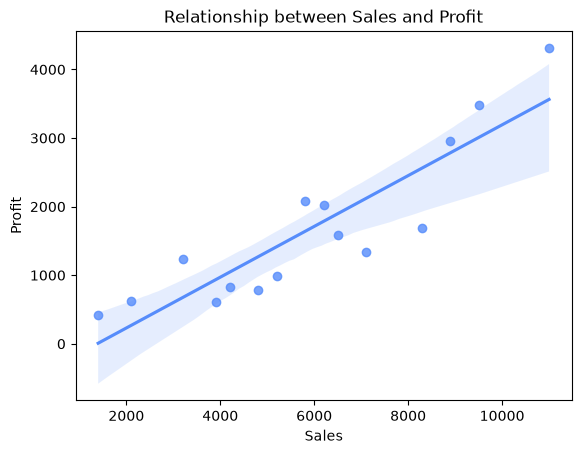

In [36]:
# Scatter plot to show relationship between Sales and Profit

sns.regplot(data=df, x="sales", y="profit")
plt.title("Relationship between Sales and Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()